In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code :", response.status_code)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")
print("Total Books :", len(books))

Status Code : 200
Total Books : 20


In [3]:
book_name = []
price = []
rating = []
availability = []

for book in books:
    name = book.h3.a["title"]
    cost = book.find("p", class_="price_color").text
    stars = book.find("p")["class"][1]
    stocks = book.find("p", class_="instock availability").text.strip()

    book_name.append(name)
    price.append(cost)
    rating.append(stars)
    availability.append(stocks)

In [ ]:
#Remote Job Market Analyzer
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
url = "https://remoteok.com/api"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

jobs = response.json()

print("Total Records:", len(jobs))

Status Code: 200
Total Records: 101


In [5]:
job_title = []
company = []
location = []
salary = []
skills = []
date = []
apply_link = []
job_type = []

for job in jobs[1:]:

    job_title.append(job.get("position", "Not Available"))

    company.append(job.get("company", "Not Available"))

    location.append(job.get("location", "Worldwide"))

    salary.append(job.get("salary_min", "Not Mentioned"))

    skills.append(", ".join(job.get("tags", [])))

    date.append(job.get("date", "Unknown"))

    apply_link.append(job.get("url", ""))

    job_type.append("Remote")

In [6]:
df = pd.DataFrame({
    "Job Title": job_title,
    "Company": company,
    "Location": location,
    "Salary": salary,
    "Skills": skills,
    "Job Type": job_type,
    "Posted Date": date,
    "Apply Link": apply_link
})

df.head()

,Job Title,Company,Location,Salary,Skills,Job Type,Posted Date,Apply Link
0,Supply Chain Analyst,DIVA,"Kitchener, Kitchener, Ontario, Canada",0,"analyst, sys admin, customer support, travel, ...",Remote,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
1,Junior Front End Developer,PULSEMEDIA (MENA),"Ø§ÙØ±ÙØ§Ø¶, Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ³...",0,"front end, dev, design, react, wordpress, full...",Remote,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-junior...
2,dishwasher,PÃ¼r &amp; Simple,"Dieppe,",0,"analyst, exec, recruiter, education",Remote,2026-07-04T22:40:52+00:00,https://remoteOK.com/remote-jobs/remote-dishwa...
3,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,0,"design, hr, sys admin, customer support, dev, ...",Remote,2026-07-04T21:10:36+00:00,https://remoteOK.com/remote-jobs/remote-human-...
4,Lead Data Scientist,Brigit,San Francisco,0,"python, education, customer support, testing, ...",Remote,2026-07-04T16:00:08+00:00,https://remoteOK.com/remote-jobs/remote-lead-d...


In [ ]:
print(df.shape)

df.info()

df.describe(include="all")

(100, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job Title    100 non-null    object
 1   Company      100 non-null    object
 2   Location     100 non-null    object
 3   Salary       100 non-null    int64 
 4   Skills       100 non-null    object
 5   Job Type     100 non-null    object
 6   Posted Date  100 non-null    object
 7   Apply Link   100 non-null    object
dtypes: int64(1), object(7)
memory usage: 6.4+ KB


,Job Title,Company,Location,Salary,Skills,Job Type,Posted Date,Apply Link
count,100,100,100,100.000000,100,100,100,100
unique,97,93,76,NaN,83,1,99,100
top,Entry Level Administrative Assistant,Recruitlytics Hiring,"New York, New York, New York, United States",NaN,,Remote,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
freq,2,4,7,NaN,13,100,2,1
mean,NaN,NaN,NaN,3600.000000,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,22134.574627,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN


In [ ]:
df.to_csv("Remote_Jobs.csv", index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


In [ ]:
df.isnull().sum()

,0
Job Title,0
Company,0
Location,0
Salary,0
Skills,0
Job Type,0
Posted Date,0
Apply Link,0


In [ ]:
df.fillna("Not Available", inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job Title    100 non-null    object
 1   Company      100 non-null    object
 2   Location     100 non-null    object
 3   Salary       100 non-null    int64 
 4   Skills       100 non-null    object
 5   Job Type     100 non-null    object
 6   Posted Date  100 non-null    object
 7   Apply Link   100 non-null    object
dtypes: int64(1), object(7)
memory usage: 6.4+ KB


In [ ]:
print("Total Jobs:", len(df))

Total Jobs: 100


In [ ]:
df["Company"].value_counts().head(10)

,count
Company,
Recruitlytics Hiring,4
The Home Depot Canada,2
New Engen,2
Kanahoma,2
CXC Upstream Ltd,2
Brigit,1
Pickle,1
Paired,1
Konkan Development Society,1


In [ ]:
df["Location"].value_counts().head(10)

,count
Location,
"New York, New York, New York, United States",7
,5
"New York, New York, United States",3
New York City Metropolitan Area,2
"New York,",2
"Montego Bay,",2
"Ø¯Ø¨Ù, Ø¯Ø¨Ù Ø§ÙØ¥Ù Ø§Ø±Ø§Øª Ø§ÙØ¹Ø±Ø¨ÙØ© Ø§ÙÙ ØªØ­Ø¯Ø©",2
"San Diego, San Diego, California, United States",2
"Lisboa, Lisboa, Lisboa, Portugal",2


In [ ]:
df["Job Title"].value_counts().head(10)

,count
Job Title,
Entry Level Administrative Assistant,2
Registrar,2
Vice President of Operations,2
Supply Chain Analyst,1
Junior Front End Developer,1
Lead Data Scientist,1
Administrative Assistant,1
Human Resources Generalist,1
dishwasher,1


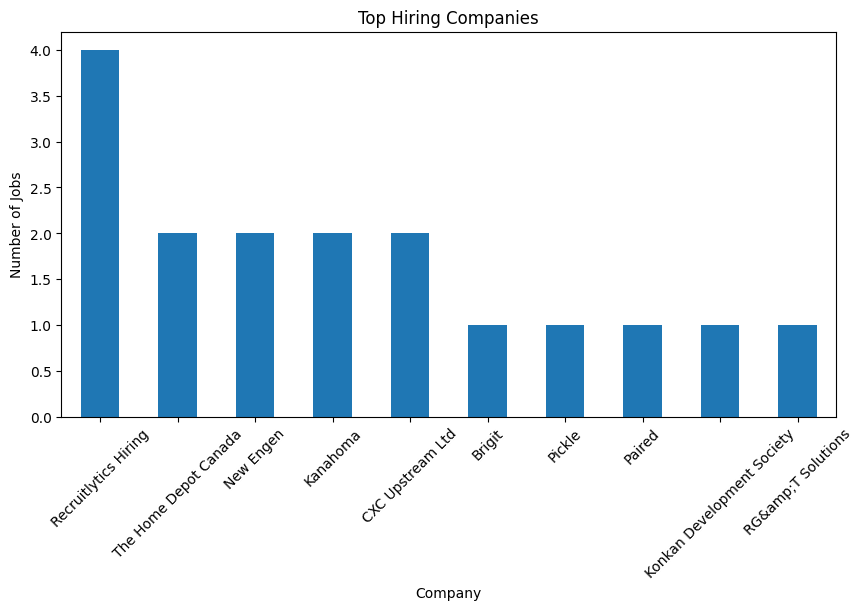

In [ ]:
top = df["Company"].value_counts().head(10)

plt.figure(figsize=(10,5))

top.plot(kind="bar")

plt.title("Top Hiring Companies")

plt.xlabel("Company")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


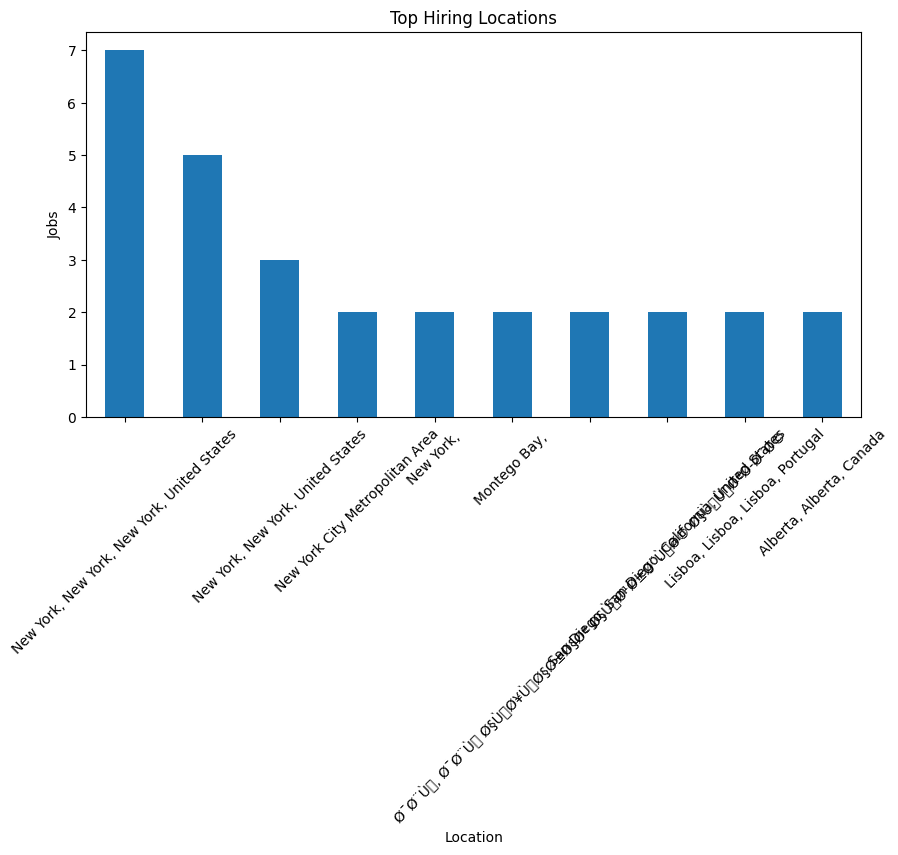

In [ ]:
top = df["Location"].value_counts().head(10)

plt.figure(figsize=(10,5))

top.plot(kind="bar")

plt.title("Top Hiring Locations")

plt.xlabel("Location")

plt.ylabel("Jobs")

plt.xticks(rotation=45)

plt.show()

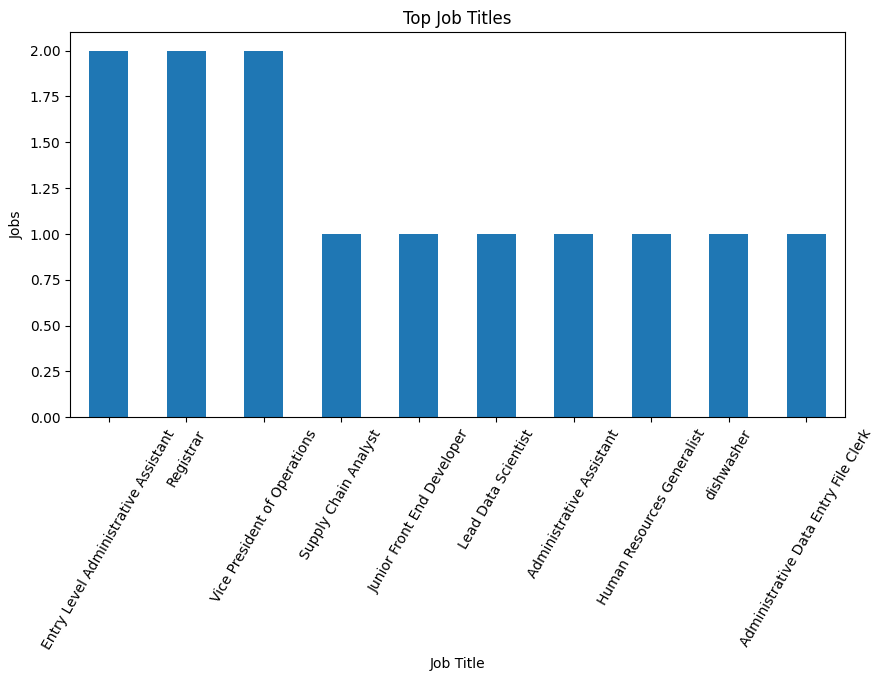

In [ ]:
top = df["Job Title"].value_counts().head(10)

plt.figure(figsize=(10,5))

top.plot(kind="bar")

plt.title("Top Job Titles")

plt.xlabel("Job Title")

plt.ylabel("Jobs")

plt.xticks(rotation=60)

plt.show()

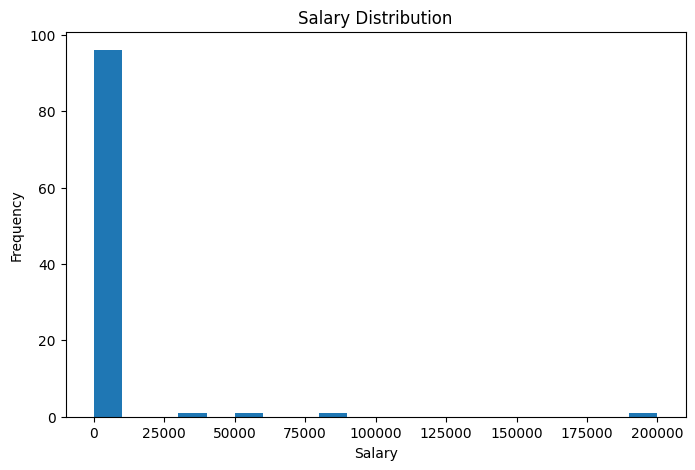

In [ ]:
salary = pd.to_numeric(df["Salary"], errors="coerce")

plt.figure(figsize=(8,5))

plt.hist(salary.dropna(), bins=20)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

In [ ]:
all_skills = []

for skill in df["Skills"]:
    for s in skill.split(","):
        s = s.strip()
        if s != "":
            all_skills.append(s)

skill_df = pd.Series(all_skills)

top_skills = skill_df.value_counts().head(10)

top_skills

,count
exec,68
customer support,60
education,55
ops,55
marketing,51
medical,50
digital nomad,50
finance,44
design,43
dev,42


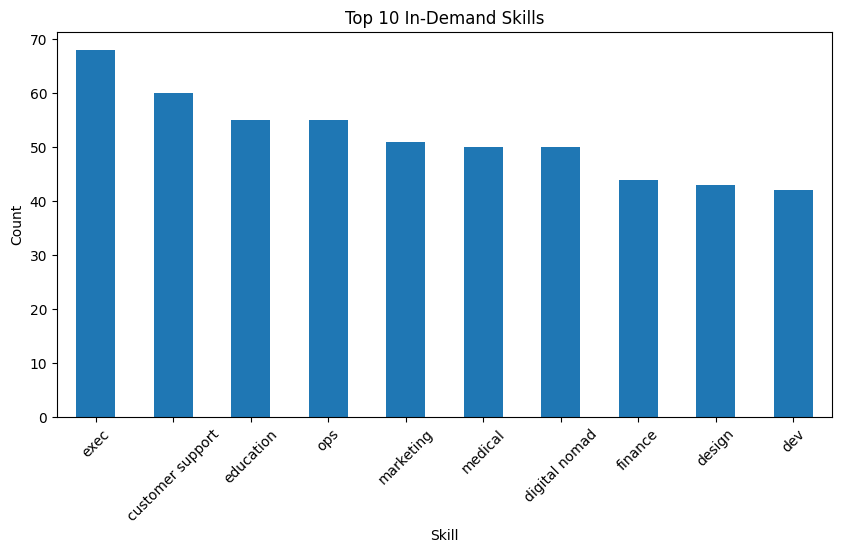

In [ ]:
plt.figure(figsize=(10,5))

top_skills.plot(kind="bar")

plt.title("Top 10 In-Demand Skills")

plt.xlabel("Skill")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print("Top Company")
print(df["Company"].value_counts().head(5))

print()

print("Top Locations")
print(df["Location"].value_counts().head(5))

print()

print("Top Job Titles")
print(df["Job Title"].value_counts().head(5))

print()

print("Top Skills")
print(top_skills)

Top Company
Company
Recruitlytics Hiring     4
The Home Depot Canada    2
New Engen                2
Kanahoma                 2
CXC Upstream Ltd         2
Name: count, dtype: int64

Top Locations
Location
New York, New York, New York, United States    7
                                               5
New York, New York, United States              3
New York City Metropolitan Area                2
New York,                                      2
Name: count, dtype: int64

Top Job Titles
Job Title
Entry Level Administrative Assistant    2
Registrar                               2
Vice President of Operations            2
Supply Chain Analyst                    1
Junior Front End Developer              1
Name: count, dtype: int64

Top Skills
exec                68
customer support    60
education           55
ops                 55
marketing           51
medical             50
digital nomad       50
finance             44
design              43
dev                 42
Name: count, dtype: 